# XAI — Spatial k-means clustering of per-model LRP maps

Cluster grid cells by how their LRP relevance varies across the **45 per-model
maps** (9 splits × 5 seeds), rather than on a single ensemble-mean composite.

### Why per-model clustering?

Clustering a single ensemble-mean map discards inter-model variability — the
very signal k-means needs to find meaningful structure.  By constructing a
feature vector of length 45 at each pixel (one relevance value per model),
k-means can identify regions where models **consistently agree** on high or
low relevance, and regions where they **disagree**.

### Clustering formulation

For each grid cell `(i, j)`:
- **feature vector** = `[lrp_model_0[i,j], lrp_model_1[i,j], …, lrp_model_44[i,j]]`
- **samples to k-means** = valid ocean pixels
- **features** = the 45 model values at each pixel

Clustering is done separately for TP signed, TN signed, TP positive-only, and
TN positive-only.

### Normalisation (critical)

Each per-model map is normalised by its **97th percentile** before any
thresholding or clustering:
- signed relevance → approximately `[-1, 1]`
- positive-only → approximately `[0, 1]`

This ensures that the threshold (e.g. `|LRP_norm| > 0.3`) is applied to the
normalised values and produces meaningful frequency maps.

### Figure layout (per case)

```
            TP                TN
 row 1 : (a) frequency     (e) frequency
 row 2 : (b) composite     (f) composite
 row 3 : (c) cluster 1     (g) cluster 1
 row 4 : (d) cluster 2     (h) cluster 2
   …    : more rows if n_clusters > 2
```

### Prerequisites

Run `cnn_predict.ipynb` first (or the prediction/LRP scripts) so models and
LRP attributions are on disk.

## Imports & config

In [ ]:
import sys
from pathlib import Path
from string import ascii_lowercase

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

from sklearn.metrics import precision_recall_curve, silhouette_score

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from configs import paths
from src.cnn.splits import load_tvt_split
from src.xai.k_means import (
    normalize_map,
    normalize_stack,
    prepare_ensemble_features,
    prepare_spatial_features,
    run_kmeans_spatial,
    reshape_clusters,
    compute_cluster_means,
    sort_clusters_by_mean,
    cluster_ensemble,
    threshold_frequency_map,
)

# Must match training
N_SPLITS  = 9
N_SEEDS   = 5
BASE_SEED = 42

PREDICTIONS_DIR = paths.RESULTS_DIR / 'predictions' / 'cesm2le'

# Publication-quality figure formatting
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

## 1. Load LRP, CNN predictions, and true labels (training data only)

For every split × seed we load:
- **Saved predictions** from `results/predictions/cesm2le/` (probabilities + optimal threshold)
- **LRP attributions** from the pre-saved attribution files
- **True training labels** from the TVT split

No model objects are loaded — predictions come from the precomputed NetCDF files
produced by `scripts/06_cnn_predict_cesm2le.py`.

In [ ]:
per_model = []   # one dict per split×seed
lat_shared, lon_shared = None, None

for split_idx in range(N_SPLITS):
    split_path = paths.tvt_split_path(split_idx)
    split = load_tvt_split(split_path)
    y_tr = split['slow_tr']

    for run_idx in range(N_SEEDS):
        lrp_path = paths.attribution_path(split_idx, run_idx)
        if not lrp_path.exists():
            continue

        # ── Load saved predictions instead of re-running inference ──
        pred_path = PREDICTIONS_DIR / f'cnn_prediction_cesm2le_M{split_idx}_{run_idx}.nc'
        with xr.open_dataset(pred_path) as ds_pred:
            scores    = ds_pred['y_prob_train'].values
            thr_best  = float(ds_pred['threshold'].values)
        y_pred = (scores >= thr_best).astype(int)

        # ── Load LRP attributions (unchanged) ──
        with xr.open_dataset(lrp_path) as lrp_ds:
            lrp_raw = lrp_ds['lrp_attributions'].values          # (nch, nt, nx, ny, 1)
            if lat_shared is None:
                lat_shared = lrp_ds['lat'].values
                lon_shared = lrp_ds['lon'].values
        lrp_flat = lrp_raw.reshape(-1, lrp_raw.shape[2], lrp_raw.shape[3])

        n_lrp = lrp_flat.shape[0]
        per_model.append({
            'lrp_flat': lrp_flat,
            'y_t'     : y_tr[:n_lrp],
            'y_pred'  : y_pred[:n_lrp],
        })

print(f'Loaded LRP for {len(per_model)} split×seed models')

## 2. Build per-model LRP stacks for TP / TN

For each of the 45 models, average LRP maps over the samples matching the
category (TP or TN).  The result is a **stack** of shape `(n_models, nx, ny)`
— one per-model mean map per model.

These stacks are the **direct input** to both clustering and frequency
computation.  The ensemble-mean composite is computed only *after* clustering
for visualisation purposes.

In [ ]:
def build_per_model_stack(per_model, category, positive_only=False):
    '''Return the stack of per-model mean LRP maps, shape (n_models, nx, ny).

    category : 'TP' or 'TN'
    positive_only : if True, negative LRP values are zeroed.
    '''
    per_map = []
    for m in per_model:
        y_t, y_pred = m['y_t'], m['y_pred']
        if category == 'TP':
            mask = (y_pred == 1) & (y_t == 1)
        elif category == 'TN':
            mask = (y_pred == 0) & (y_t == 0)
        else:
            raise ValueError(category)
        if mask.sum() == 0:
            continue
        sel = m['lrp_flat'][mask]
        if positive_only:
            sel = np.where(sel > 0, sel, 0.0)
        per_map.append(sel.mean(axis=0))
    stack = np.stack(per_map, axis=0)         # (n_models, nx, ny)
    return stack


# Build the four raw (un-normalised) stacks
tp_signed_stack = build_per_model_stack(per_model, 'TP', positive_only=False)
tn_signed_stack = build_per_model_stack(per_model, 'TN', positive_only=False)
tp_pos_stack    = build_per_model_stack(per_model, 'TP', positive_only=True)
tn_pos_stack    = build_per_model_stack(per_model, 'TN', positive_only=True)

print(f'Per-model stacks: {tp_signed_stack.shape[0]} models, '
      f'grid {tp_signed_stack.shape[1]}×{tp_signed_stack.shape[2]}')
print(f'  TP signed : {tp_signed_stack.shape}')
print(f'  TN signed : {tn_signed_stack.shape}')
print(f'  TP pos    : {tp_pos_stack.shape}')
print(f'  TN pos    : {tn_pos_stack.shape}')

## 3. Quick diagnostic: inertia / silhouette vs. k

Justify the default `n_clusters` by scanning a small range of `k` for each
case.  Features are the **per-model vectors at each pixel** (length 45),
matching the actual clustering formulation.

In [ ]:
from sklearn.cluster import KMeans

def kmeans_diagnostic(lrp_stack, method='maxabs', k_range=(2, 3, 4, 5)):
    """Scan k values using per-model ensemble features."""
    stack_norm = normalize_stack(lrp_stack, method=method)
    feats, _ = prepare_ensemble_features(stack_norm)
    out = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(feats)
        # silhouette on a sub-sample to keep it fast
        n = feats.shape[0]
        idx = np.random.default_rng(0).choice(n, size=min(5000, n), replace=False)
        sil = silhouette_score(feats[idx], km.labels_[idx]) if k > 1 else np.nan
        out[k] = {'inertia': float(km.inertia_), 'silhouette': float(sil)}
    return out

for label, stack, meth in [
    ('TP signed', tp_signed_stack, 'maxabs'),
    ('TN signed', tn_signed_stack, 'maxabs'),
    ('TP pos',    tp_pos_stack,    'max'),
    ('TN pos',    tn_pos_stack,    'max'),
]:
    print(f'\n{label}:')
    for k, s in kmeans_diagnostic(stack, method=meth).items():
        print(f'  k={k}: inertia={s["inertia"]:12.2f}   silhouette={s["silhouette"]:.3f}')

## 4. Cluster the four cases using the per-model stacks

K-means is now applied to the **full stack of per-model maps**, not to a
single ensemble mean.  At each pixel the feature vector has length 45 (one
entry per model).  This preserves inter-model variability.

`cluster_ensemble` does:  normalise each model map (97th pctile) → build
`(n_pixels, 45)` feature matrix → k-means → reshape → sort by mean LRP.

In [ ]:
N_CLUSTERS_SIGNED = 2      # try 3 if signed LRP shows clear +/0/− structure
N_CLUSTERS_POS    = 2

# ── Cluster using the full per-model stacks ──
# cluster_ensemble returns: (stack_norm, composite_norm, cluster_map)

tp_signed_snorm, tp_signed_norm, tp_signed_clusters = cluster_ensemble(
    tp_signed_stack, n_clusters=N_CLUSTERS_SIGNED, method='maxabs')
tn_signed_snorm, tn_signed_norm, tn_signed_clusters = cluster_ensemble(
    tn_signed_stack, n_clusters=N_CLUSTERS_SIGNED, method='maxabs')
tp_pos_snorm, tp_pos_norm, tp_pos_clusters = cluster_ensemble(
    tp_pos_stack, n_clusters=N_CLUSTERS_POS, method='max')
tn_pos_snorm, tn_pos_norm, tn_pos_clusters = cluster_ensemble(
    tn_pos_stack, n_clusters=N_CLUSTERS_POS, method='max')

print('TP signed cluster means:', compute_cluster_means(tp_signed_norm, tp_signed_clusters))
print('TN signed cluster means:', compute_cluster_means(tn_signed_norm, tn_signed_clusters))
print('TP pos    cluster means:', compute_cluster_means(tp_pos_norm,    tp_pos_clusters))
print('TN pos    cluster means:', compute_cluster_means(tn_pos_norm,    tn_pos_clusters))

## 5. Threshold-frequency maps

Frequency across the 45 per-model maps of `|LRP_norm| > 0.3` (signed) or
`LRP_norm > 0.3` (positive-only).

**Critical:** each per-model map is normalised by its 97th percentile
**before** thresholding (`normalize_stack` inside `threshold_frequency_map`).
This ensures the threshold is applied to values on the same normalised scale
shown in the composite panels, fixing the previous inconsistency where
thresholds were applied to pre-normalised values.

In [ ]:
THRESH = 0.3

# Signed: normalise with maxabs (97th pctile), threshold on |LRP_norm|
tp_signed_freq = threshold_frequency_map(
    tp_signed_stack, threshold=THRESH, mode='absolute',
    normalize=True, norm_method='maxabs')
tn_signed_freq = threshold_frequency_map(
    tn_signed_stack, threshold=THRESH, mode='absolute',
    normalize=True, norm_method='maxabs')

# Positive-only: normalise with max (97th pctile), threshold on LRP_norm
tp_pos_freq = threshold_frequency_map(
    tp_pos_stack, threshold=THRESH, mode='positive',
    normalize=True, norm_method='max')
tn_pos_freq = threshold_frequency_map(
    tn_pos_stack, threshold=THRESH, mode='positive',
    normalize=True, norm_method='max')

# Sanity check: frequency maps should have substantial spatial variation
for label, freq in [('TP signed', tp_signed_freq), ('TN signed', tn_signed_freq),
                     ('TP pos', tp_pos_freq), ('TN pos', tn_pos_freq)]:
    print(f'{label}: min={np.nanmin(freq):.3f}  mean={np.nanmean(freq):.3f}  '
          f'max={np.nanmax(freq):.3f}')

## 6. Plotting

Plot helper that produces the two-column, multi-row figure described in the
intro. It matches the projection, coastlines, and colormap conventions used
in the SST/LRP composite cells of `cnn_predict.ipynb`:
- signed LRP → `cmocean.cm.curl` on `[−1, 1]`
- positive LRP → `magma` on `[0, 1]`
- frequency → `viridis` on `[0, 1]`

Cluster rows show the **masked LRP map** for that cluster (values inside
the cluster, NaN elsewhere) so the visual scale matches the composite panel
directly above.

In [ ]:
def plot_kmeans_figure(
    tp_freq, tn_freq,
    tp_norm, tn_norm,
    tp_clusters, tn_clusters,
    lat, lon,
    signed=True,
    title_suffix='',
):
    '''2-column, (2 + n_clusters)-row figure.  Columns = TP | TN.'''
    n_c = max(int(np.nanmax(tp_clusters)), int(np.nanmax(tn_clusters))) + 1
    n_rows = 2 + n_c
    proj  = ccrs.PlateCarree(central_longitude=180)
    lon2d, lat2d = np.meshgrid(lon, lat)

    fig, axes = plt.subplots(
        n_rows, 2, figsize=(14, 3.2 * n_rows),
        subplot_kw={'projection': proj},
    )

    # colormaps / limits
    if signed:
        comp_cmap = cmocean.cm.curl
        comp_vmin, comp_vmax = -1.0, 1.0
        comp_label = 'Normalised relevance (signed)'
    else:
        comp_cmap = 'magma'
        comp_vmin, comp_vmax = 0.0, 1.0
        comp_label = 'Normalised relevance (positive)'

    freq_cmap = 'viridis'

    # Flatten panel list in reading order (row by row, TP then TN)
    panel_specs = []
    panel_specs.append(('freq', axes[0, 0], tp_freq, 'TP'))
    panel_specs.append(('freq', axes[0, 1], tn_freq, 'TN'))
    panel_specs.append(('comp', axes[1, 0], tp_norm, 'TP'))
    panel_specs.append(('comp', axes[1, 1], tn_norm, 'TN'))
    for ci in range(n_c):
        tp_mask = np.where(tp_clusters == ci, tp_norm, np.nan)
        tn_mask = np.where(tn_clusters == ci, tn_norm, np.nan)
        panel_specs.append(('cluster', axes[2 + ci, 0], tp_mask, f'TP · cluster {ci}'))
        panel_specs.append(('cluster', axes[2 + ci, 1], tn_mask, f'TN · cluster {ci}'))

    letters = iter(ascii_lowercase)

    for kind, ax, data, tag in panel_specs:
        letter = next(letters)
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
        ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

        if kind == 'freq':
            im = ax.pcolormesh(lon2d, lat2d, data,
                               cmap=freq_cmap, vmin=0.0, vmax=1.0,
                               transform=ccrs.PlateCarree(), shading='auto', zorder=0)
            cb_label = f'P(|LRP_norm| > {THRESH})' if signed else f'P(LRP_norm > {THRESH})'
        else:
            im = ax.pcolormesh(lon2d, lat2d, data,
                               cmap=comp_cmap, vmin=comp_vmin, vmax=comp_vmax,
                               transform=ccrs.PlateCarree(), shading='auto', zorder=0)
            cb_label = comp_label

        ax.set_title(f'({letter})')

        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04,
                     fraction=0.046, label=cb_label)

    plt.tight_layout()
    return fig

### Case 1: signed LRP (positive + negative)

Clusters are based on the 45-model feature vectors at each pixel (not on the
ensemble mean).  Row 1 shows how often each grid cell exceeds
`|LRP_norm| > 0.3` across the 45 models, where each model's map is normalised
by its own 97th percentile before thresholding.

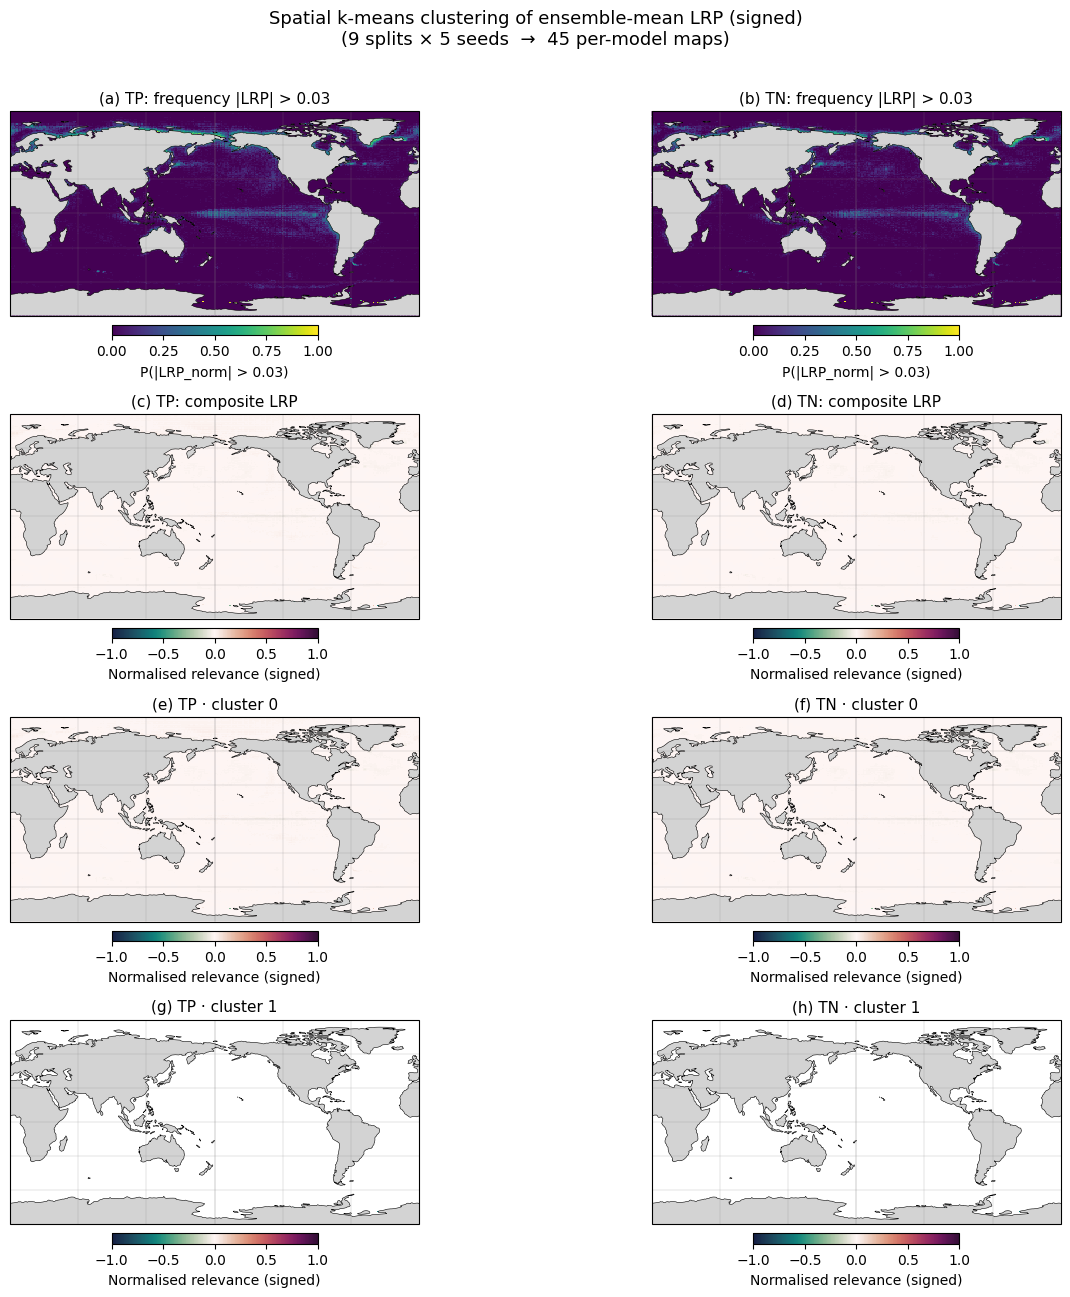

In [12]:
fig = plot_kmeans_figure(
    tp_signed_freq, tn_signed_freq,
    tp_signed_norm, tn_signed_norm,
    tp_signed_clusters, tn_signed_clusters,
    lat_shared, lon_shared,
    signed=True,
    title_suffix='(signed)',
)
plt.show()

### Case 2: positive-only LRP

Matches the positive-only figures in `cnn_predict.ipynb`.  Clusters separate
regions by the consistency and magnitude of positive relevance across models.
Row 1 shows `LRP_norm > 0.3` with per-model 97th-percentile normalisation.

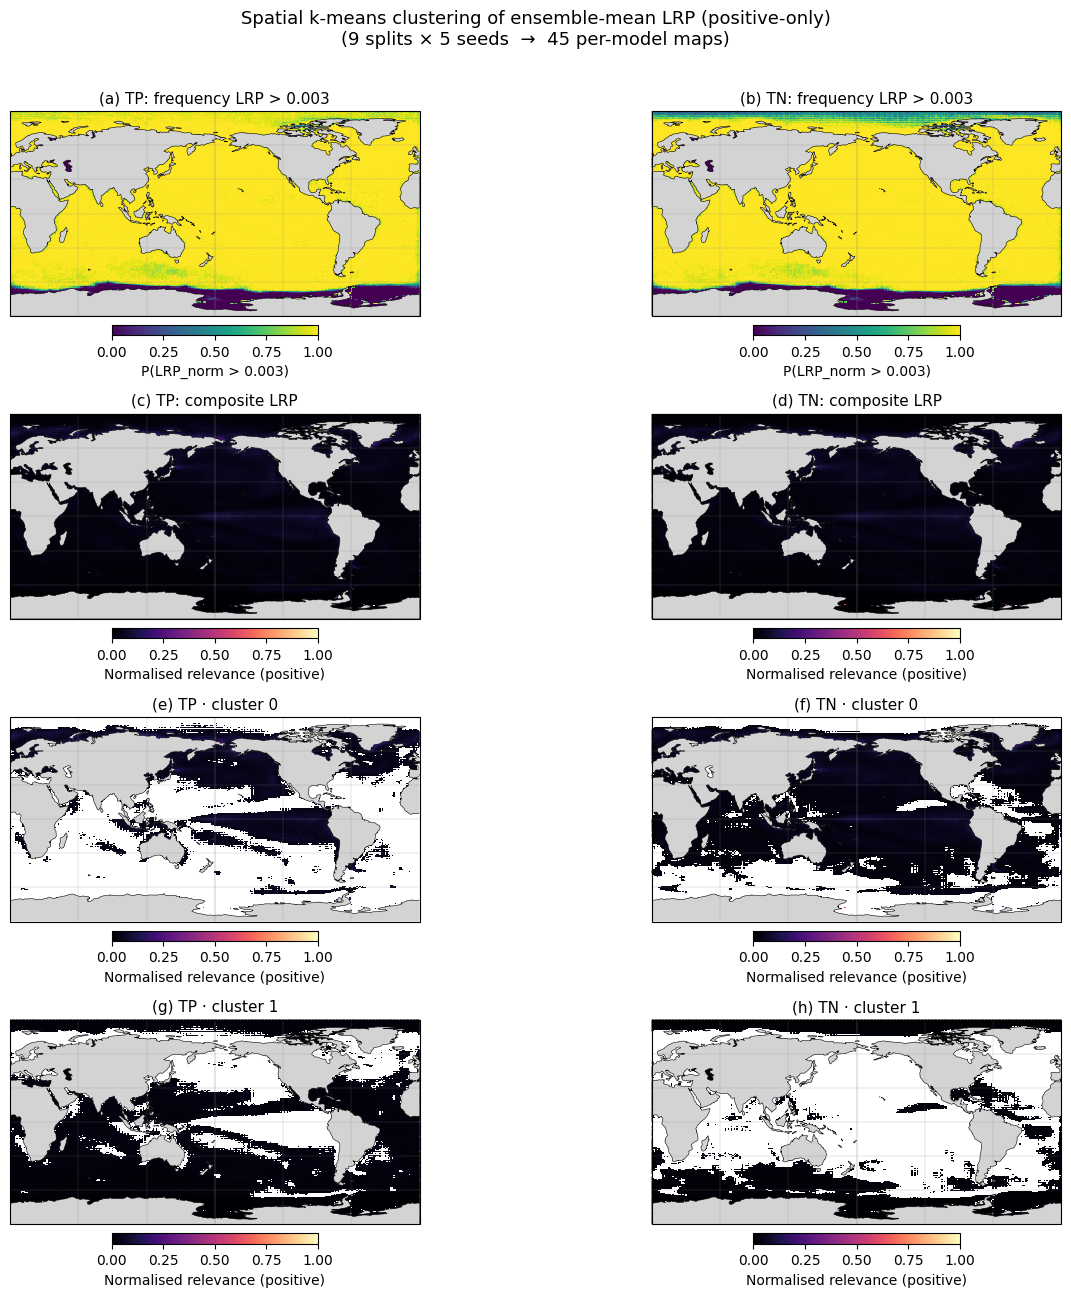

In [16]:
fig = plot_kmeans_figure(
    tp_pos_freq, tn_pos_freq,
    tp_pos_norm, tn_pos_norm,
    tp_pos_clusters, tn_pos_clusters,
    lat_shared, lon_shared,
    signed=False,
    title_suffix='(positive-only)',
)
plt.show()

## Summary

- **Clustering target.** Spatial k-means on the **45 per-model LRP maps** (not the ensemble mean).  Each pixel's feature vector has length 45, preserving inter-model variability.
- **Normalisation.** Each per-model map is normalised by its 97th percentile before clustering and before thresholding.  Signed → `[-1, 1]`; positive-only → `[0, 1]`.
- **Threshold-frequency.** Computed across the 45 per-model maps with per-model 97th-percentile normalisation applied before the threshold test.  This fixes the earlier inconsistency where thresholds were applied to pre-normalised values.
- **n_clusters.** Default `k = 2` for both cases; the diagnostic cell reports inertia and silhouette so this can be raised if the data supports it.

### Interpretation note

If TP and TN relevance patterns remain similar after fixing clustering and
normalisation, this suggests that the CNN is using similar geographic regions
for both classes.  The distinction between slowdown and non-slowdown likely
depends on **SST anomaly structure**, **magnitude**, and **spatial
configuration** within those regions — not on entirely different geographic
areas being relevant.